运行ISTA...
运行FISTA...
计算参考解...


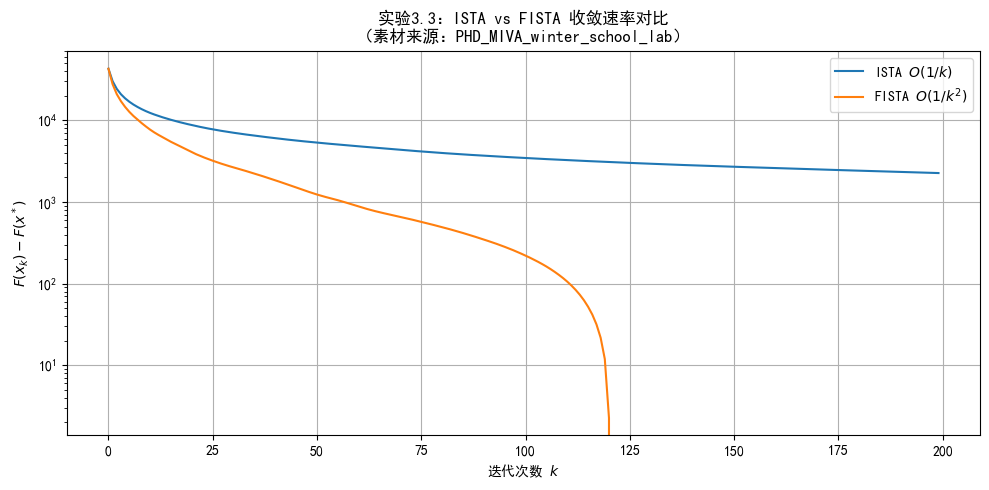

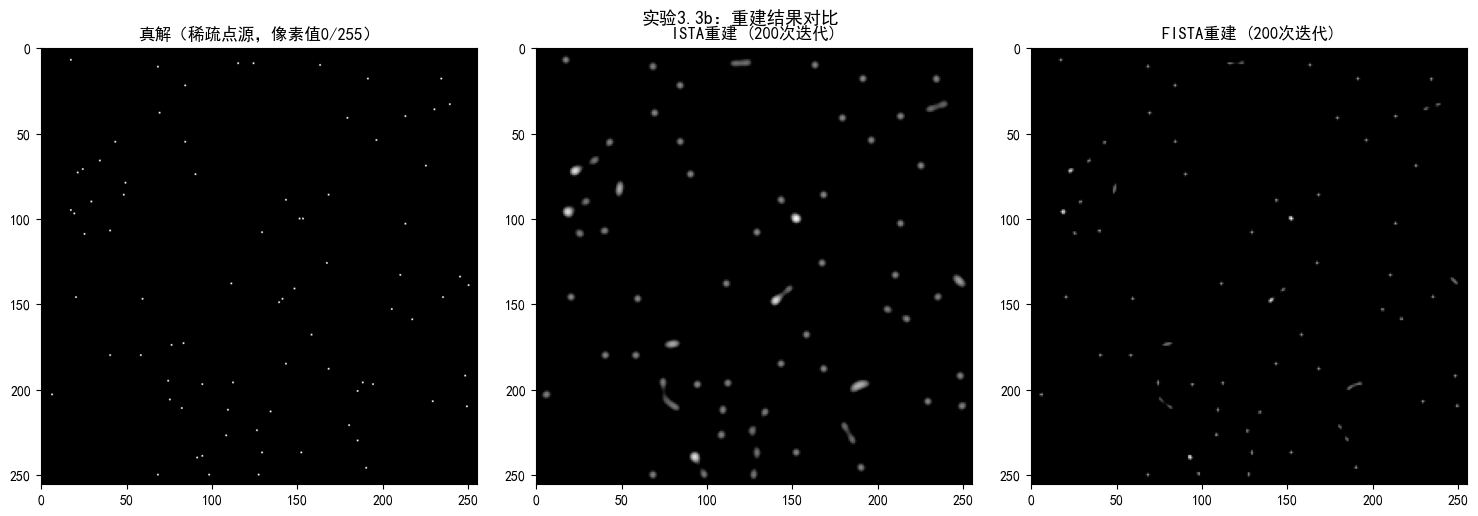

In [2]:
"""
实验3.3 ISTA/FISTA求解LASSO去模糊
对应章节：3.4（近端梯度下降ISTA、Nesterov加速FISTA、收敛率对比）
素材来源：winter_school/Smooth and non-smooth optimisation for imaging applications/
          PHD_MIVA_winter_school_lab - solutions.ipynb
"""

import math
import random
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

# ---- 1. 正向模型（取自winter school lab）----
random.seed(17)
np.random.seed(24)

n = 256
gt = np.zeros([n, n])
N_mol = 80
margin = 5
for k in range(N_mol):
    i = random.randint(margin, n - margin)
    j = random.randint(margin, n - margin)
    gt[i, j] = 255

# 高斯PSF
s = 4
x_coords = np.concatenate((np.arange(0, n//2), np.arange(-n//2, 0)))
[Y, X] = np.meshgrid(x_coords, x_coords)
h = np.exp(-(X**2 + Y**2) / (2 * s**2))
h = h / np.sum(h)

# 模糊算子（取自winter school lab）
def blur(x):
    return np.real(np.fft.ifft2(np.fft.fft2(np.fft.fftshift(h)) * np.fft.fft2(x)))

# 下采样矩阵（取自winter school lab）
L = 4
m = n // L
M_L = np.zeros([m, n])
for i in range(m):
    M_L[i, L*i:L*i+L] = 1

def down_sampling(x):
    return M_L @ x @ M_L.T

def forward(x):
    return down_sampling(blur(x))

# 含噪观测
sigma_noise = 0.7
acq = forward(gt) + sigma_noise * np.random.randn(m, m)

# Lipschitz常数（取自winter school lab）
hF = np.real(np.fft.fft2(np.fft.fftshift(h)))
Lips = np.max(hF**2) * L**2

# 梯度与目标函数（取自winter school lab）
def gradient(x):
    residual = forward(x) - acq
    aus = M_L.T @ residual @ M_L
    return np.real(np.fft.ifft2(np.conj(np.fft.fft2(np.fft.fftshift(h))) * np.fft.fft2(aus)))

def fidelity(x):
    return 0.5 * np.sum((forward(x) - acq)**2)

def cost_function(x, lmbda):
    return fidelity(x) + lmbda * np.sum(np.abs(x))

# 软阈值（取自winter school lab，等价于Smu.m的Python版）
def soft_thresholding(x, gamma):
    return np.sign(x) * np.maximum(0, np.abs(x) - gamma)

# ---- 2. ISTA（取自winter school lab）----
def ISTA(x0, tau, lmbda, maxiter):
    xk = x0.copy()
    cost = np.zeros(maxiter)
    for k in range(maxiter):
        xkk = xk - tau * gradient(xk)          # 梯度步
        xkk = soft_thresholding(xkk, tau*lmbda) # 近端步（软阈值）
        xkk = np.maximum(0, xkk)                # 非负约束
        cost[k] = cost_function(xkk, lmbda)
        xk = xkk
    return xk, cost

# ---- 3. FISTA（取自winter school lab）----
def FISTA(x0, tau, lmbda, maxiter):
    xk = x0.copy()
    xold = x0.copy()
    told = 1
    cost = np.zeros(maxiter)
    for k in range(maxiter):
        tk = 0.5 * (1 + math.sqrt(1 + 4 * told**2))
        yk = xk + (told - 1) / tk * (xk - xold)  # 外推步
        z = yk - tau * gradient(yk)                # 梯度步
        z = soft_thresholding(z, tau * lmbda)      # 近端步
        z = np.maximum(0, z)                       # 非负约束
        told = tk
        xold = xk.copy()
        xk = z
        cost[k] = cost_function(xk, lmbda)
    return xk, cost

# ---- 4. 运行与收敛对比（取自winter school lab）----
x0 = np.zeros((n, n))
tau = 0.9 / Lips
lmbda = 10
maxiter = 200

print("运行ISTA...")
rec_ista, cost_ista = ISTA(x0, tau, lmbda, maxiter)
print("运行FISTA...")
rec_fista, cost_fista = FISTA(x0, tau, lmbda, maxiter)

# 参考解（长运行ISTA）
print("计算参考解...")
_, cost_ref = ISTA(x0, tau, lmbda, 2000)
F_star = cost_ref[-1]

# 收敛曲线对比
plt.figure(figsize=(10, 5))
plt.plot(cost_ista - F_star, label='ISTA $O(1/k)$')
plt.plot(cost_fista - F_star, label='FISTA $O(1/k^2)$')
plt.yscale('log')
plt.xlabel('迭代次数 $k$')
plt.ylabel('$F(x_k) - F(x^*)$')
plt.title('实验3.3：ISTA vs FISTA 收敛速率对比\n（素材来源：PHD_MIVA_winter_school_lab）')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 重建结果（不设vmin/vmax，让matplotlib自动缩放——重建值远小于255）
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt, cmap='gray')
axes[0].set_title('真解（稀疏点源，像素值0/255）')
axes[1].imshow(rec_ista, cmap='gray')
axes[1].set_title('ISTA重建 (200次迭代)')
axes[2].imshow(rec_fista, cmap='gray')
axes[2].set_title('FISTA重建 (200次迭代)')
plt.suptitle('实验3.3b：重建结果对比', fontsize=13)
plt.tight_layout()
plt.show()
